    Crop           State  Cost_A2_FL   Cost_C2  Production_Cost  Yield
0  ARHAR   Uttar Pradesh     9794.05  23076.74          1941.55   9.83
1  ARHAR       Karnataka    10593.15  16528.68          2172.46   7.47
2  ARHAR         Gujarat    13468.82  19551.90          1898.30   9.59
3  ARHAR  Andhra Pradesh    17051.66  24171.65          3670.54   6.42
4  ARHAR     Maharashtra    17130.55  25270.26          2775.80   8.72


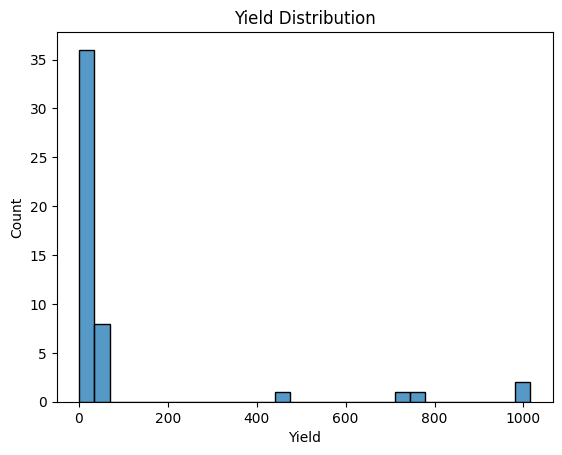

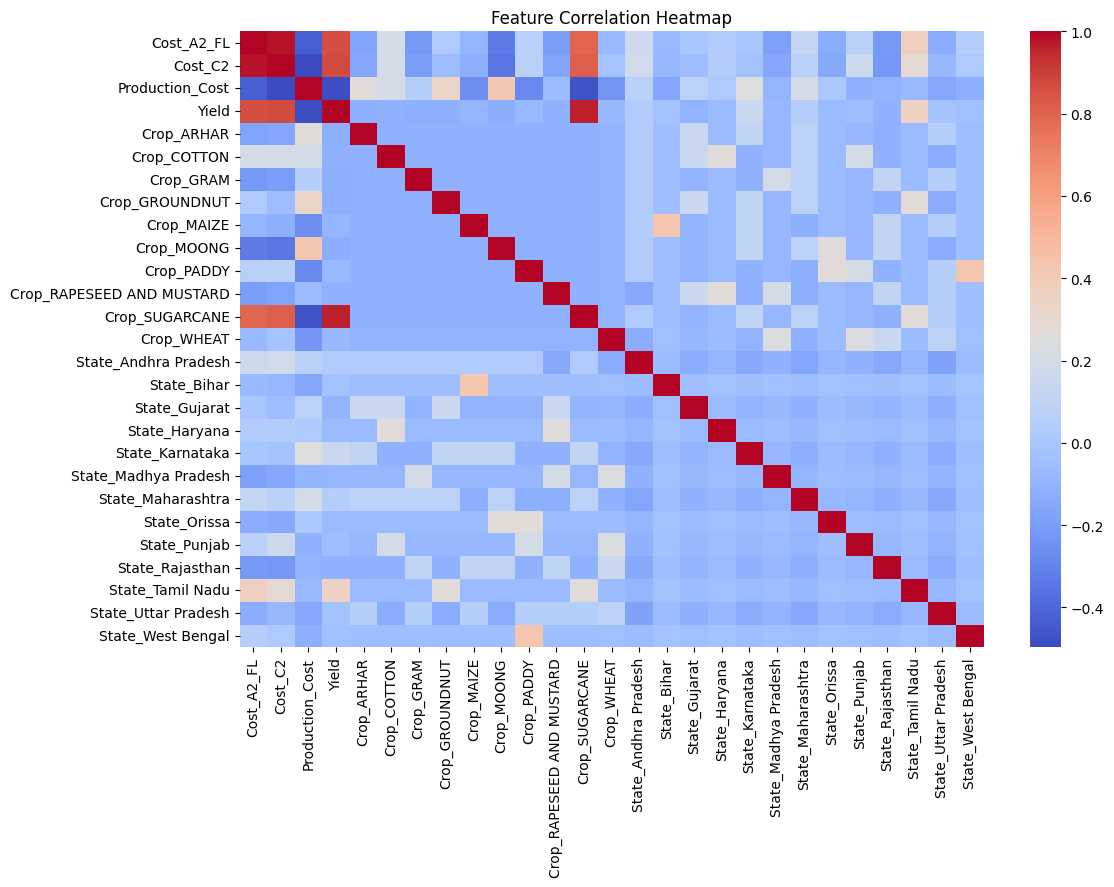


Model Performance:
MAE: 23.197480000000017
RMSE: 60.420487342970056


In [7]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("../data/crop_data.csv")

# ==============================
# 3. Rename Columns (IMPORTANT)
# ==============================
df.columns = [
    "Crop",
    "State",
    "Cost_A2_FL",
    "Cost_C2",
    "Production_Cost",
    "Yield"
]

print(df.head())

# ==============================
# 4. Clean Data
# ==============================
df = df.dropna()

# ==============================
# 5. Encode Categorical Data
# ==============================

df = pd.get_dummies(df, columns=["Crop", "State"])
# ==============================
# 6. EDA (Visualization)
# ==============================

# Yield distribution
plt.figure()
sns.histplot(df["Yield"], bins=30)
plt.title("Yield Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ==============================
# 7. Features & Target
# ==============================
X = df.drop("Yield", axis=1)
y = df["Yield"]

# ==============================
# 8. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 9. Model Training
# ==============================
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# ==============================
# 10. Prediction
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 11. Evaluation
# ==============================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance:")
print("MAE:", mae)
print("RMSE:", rmse)